In [ ]:
import timeit
from ppg_basis import ppgGenerator, ppgExtractor
from ppg_constants import basis_types, default_M
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

# Constants

In [ ]:
Ls = [2, 3, 4, 5, 10]

thetai = np.pi / 2

basis_type_params = {
    "gaussian" : [.5, 1.5],
    "gamma" : [0.5, 3, 0.75],
    "skewed-gaussian" : [0.5, 1.5, 3]
}

num_times = 100

durations = [10, 25, 50, 75, 100, 250, 500, 750, 1000, 5000, 10000]

methods = ["template", "fft", "rk3", "rk4", "basis"]

Ms = [64, 128, 256, 512, 1024]

line_styles = ["--", "-"]

Ls_colors = plt.cm.rainbow(np.linspace(0, 1, len(Ls)))

# Profiling Pipelines

In [ ]:
def gen_pipeline(
    duration: int, 
    L: int, 
    basis_type: str, 
    solver: str, 
    M: int
) -> np.ndarray:
    ppgGen = ppgGenerator(fs=60,
                          hr=60,
                          mu=1,
                          sigma=0,
                          duration=duration,
                          L= L,
                          basis_type=basis_type,
                          solver = solver,
                          thetas = np.array([thetai for _ in range(L)]),
                          params = [basis_type_params[basis_type].copy() for _ in range(L)])
    return ppgGen.generate_signal(M)

sig = gen_pipeline(10, 2, "gaussian", "rk3", 512) # running once to remove issues with njit messing up runtime

def ext_pipeline(
    L: int, 
    basis_type: str, 
    solver: str
) -> tuple[np.ndarray, np.ndarray]:
    ppgExt = ppgExtractor(signal=sig,
                        fs=125,
                        hr=60,
                        sigma=0,
                        L=L,
                        basis_type=basis_type,
                        solver=solver,
                        cost_metrics=["mse", "corr", "kendall"],
                        cost_weights=[1, 1, 0.5],)
    return ppgExt.extract_ppg(block_update=True, coord_cycles=4)

theta, params = ext_pipeline(2, "gaussian", "rk3")

<class 'tuple'>


# Generator Analysis

In [ ]:
def gen_method_analysis_df(basis_type: str) -> pd.DataFrame:
    rows = []

    for L in Ls:
        for duration in durations:
            basis_runtime = timeit.timeit(
                lambda: gen_pipeline(duration, L, basis_type, "basis", default_M),
                number=num_times
            )

            for method in methods:
                runtime = timeit.timeit(
                    lambda: gen_pipeline(duration, L, basis_type, method, default_M),
                    number=num_times
                )

                rows.append({
                    "basis_type": basis_type,
                    "method": method,
                    "L": L,
                    "duration": duration,
                    "runtime": runtime,
                    "basis_runtime": basis_runtime,
                    "runtime_to_basis_ratio": runtime / basis_runtime
                })

    return pd.DataFrame(rows)

gen_df = pd.concat([
    gen_method_analysis_df("gaussian"),
    gen_method_analysis_df("gamma"),
    gen_method_analysis_df("skewed-gaussian")
], ignore_index=True)

gen_df.to_csv("./recover_test_csv/gen_method_runtime_ratio_analysis.csv", index=False)

In [14]:
def plot_gen_metric(
    df: pd.DataFrame,
    basis_types: list[str],
    Ls: list[int],
    plot_methods: list[str],
    y_column: str,
    y_label: str,
    title: str,
    output_path: str
) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(18,5))

    for ax, basis_type in zip(axes, basis_types):
        for method_idx, method in enumerate(plot_methods):
            for line_idx, L in enumerate(Ls):
                line_df = df[
                    (df["basis_type"] == basis_type) &
                    (df["method"] == method) &
                    (df["L"] == L)
                ].sort_values("duration")

                ax.plot(
                    line_df["duration"],
                    line_df[y_column],
                    linestyle=line_styles[method_idx],
                    color=Ls_colors[line_idx]
                )

        ax.set_xscale("log")
        ax.set_xlim(10, 10000)
        ax.set_xlabel("Duration (s)")
        ax.set_title(f"{basis_type}")
        ax.grid(True, which="both", ls="--")

    axes[0].set_ylabel(y_label)

    method_handles = [
        Line2D([0], [0], color="black", linestyle=line_styles[i], lw=2)
        for i in range(len(plot_methods))
    ]
    legend1 = axes[2].legend(
        method_handles,
        plot_methods,
        title="Methods",
        loc="upper left",
        bbox_to_anchor=(1.05, 1)
    )
    axes[2].add_artist(legend1)

    Ls_handles = [Line2D([0], [0], color=Ls_colors[i], lw=2) for i in range(len(Ls))]
    axes[2].legend(
        Ls_handles,
        Ls,
        title="Kernels",
        loc="lower left",
        bbox_to_anchor=(1.05, 0)
    )

    fig.suptitle(title, fontsize=16)

    plt.tight_layout()
    plt.savefig(output_path, dpi=1400)
    plt.show()

In [19]:
gen_df = pd.read_csv("./recover_test_csv/gen_method_runtime_ratio_analysis.csv")

## Generator: Template/FFT vs Base

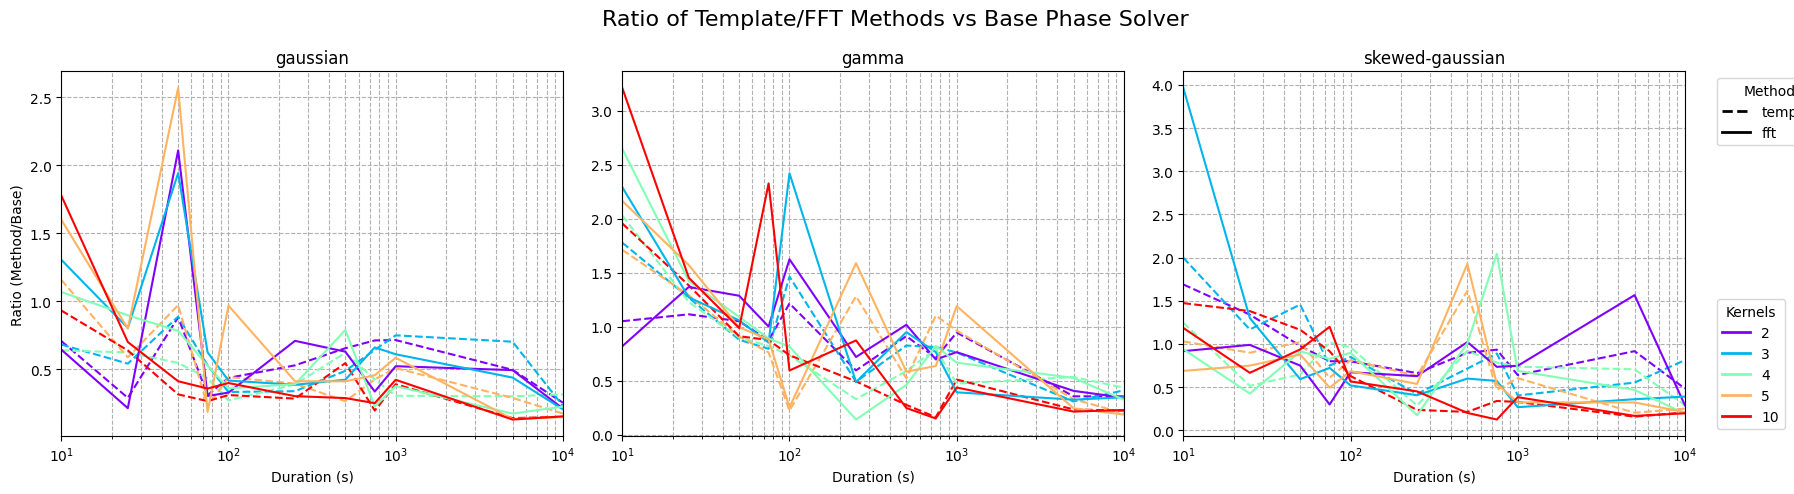

In [20]:
plot_gen_metric(
    gen_df,
    basis_types,
    Ls,
    ["template", "fft"],
    "runtime_to_basis_ratio",
    "Ratio (Method/Base)",
    "Ratio of Template/FFT Methods vs Base Phase Solver",
    "./recover_test_images/phase_vs_base.svg"
)

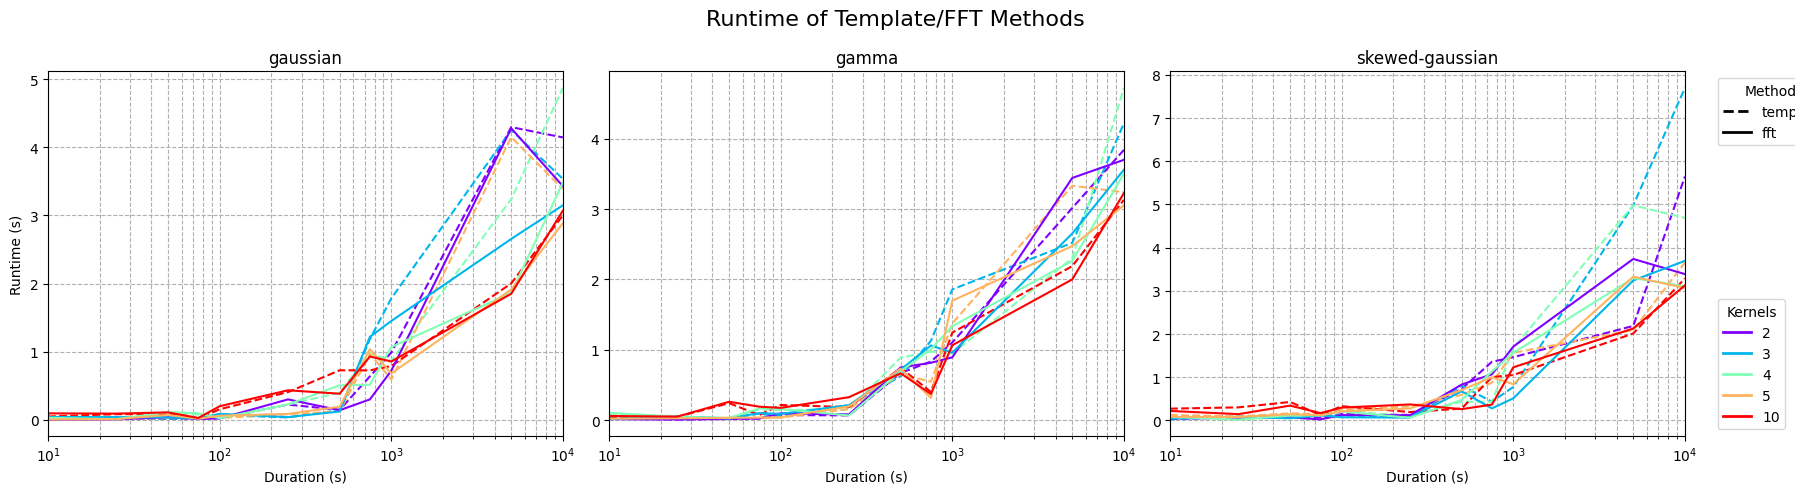

In [21]:
plot_gen_metric(
    gen_df,
    basis_types,
    Ls,
    ["template", "fft"],
    "runtime",
    "Runtime (s)",
    "Runtime of Template/FFT Methods",
    "./recover_test_images/phase_runtimes.svg"
)

## Generator: ODE vs Base

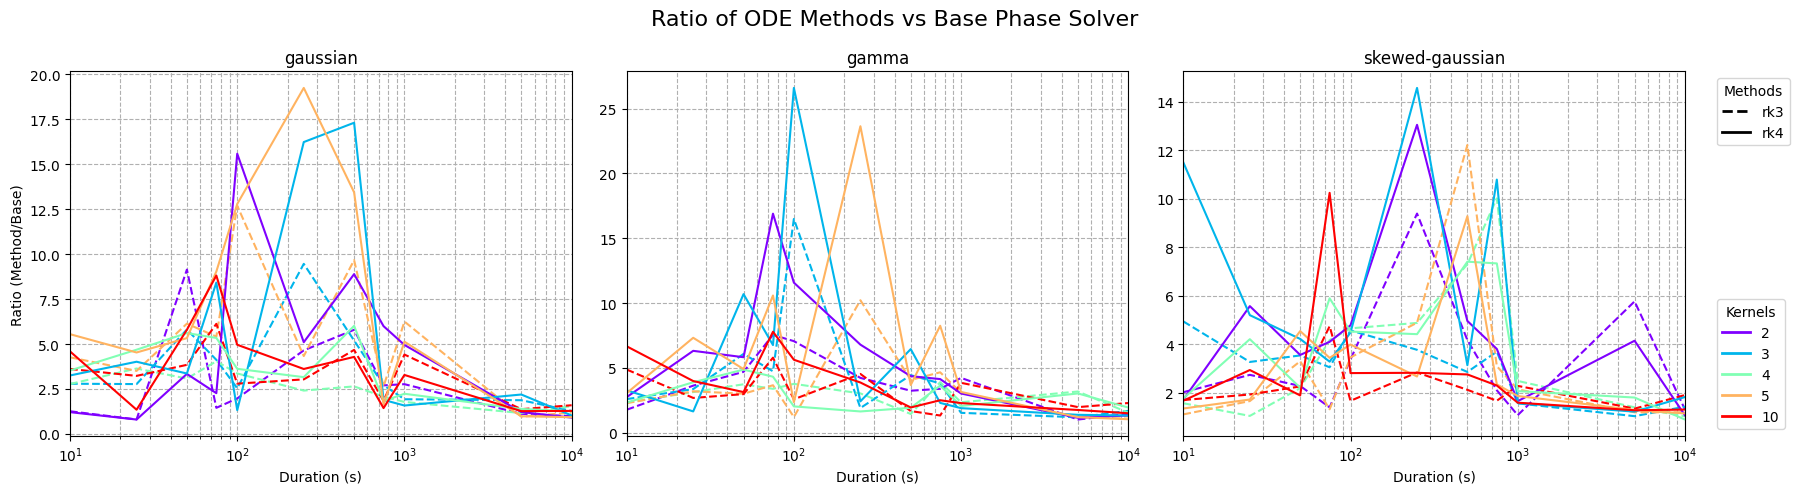

In [22]:
plot_gen_metric(
    gen_df,
    basis_types,
    Ls,
    ["rk3", "rk4"],
    "runtime_to_basis_ratio",
    "Ratio (Method/Base)",
    "Ratio of ODE Methods vs Base Phase Solver",
    "./recover_test_images/ode_vs_base.svg"
)

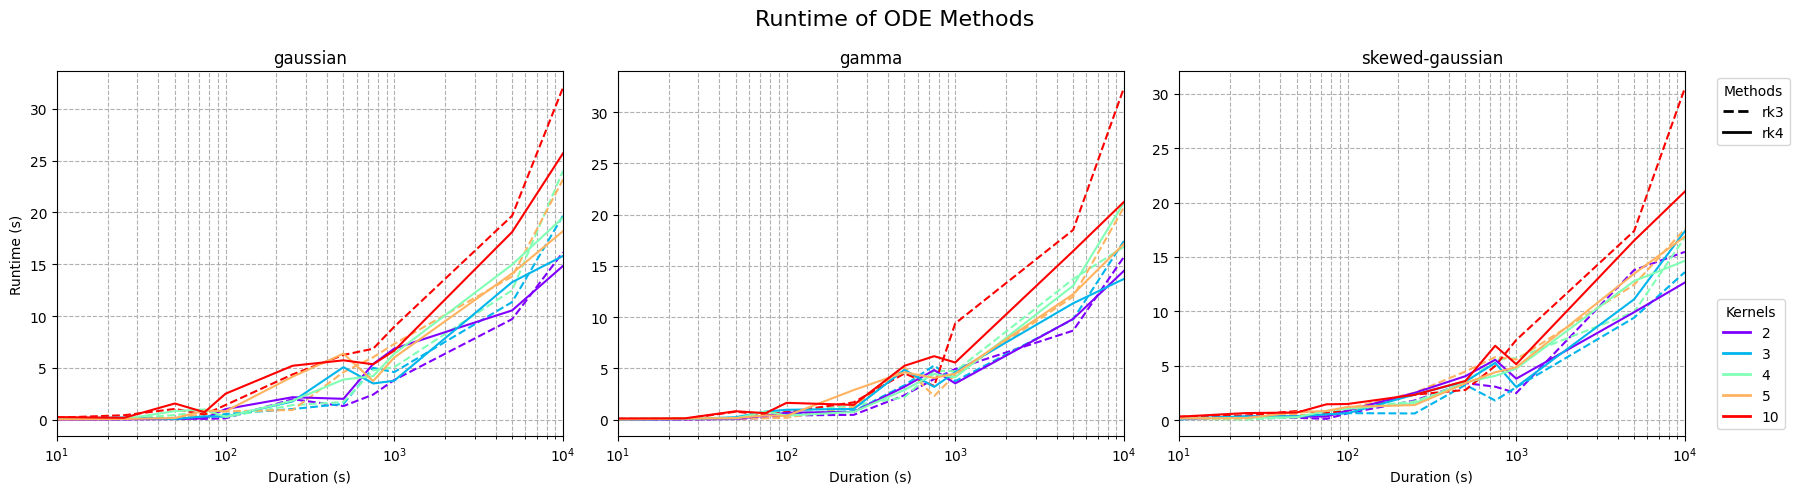

In [23]:
plot_gen_metric(
    gen_df,
    basis_types,
    Ls,
    ["rk3", "rk4"],
    "runtime",
    "Runtime (s)",
    "Runtime of ODE Methods",
    "./recover_test_images/ode_runtimes.svg"
)

## Generator: Template/FFT
 Accuracy

In [ ]:
def gen_accuracy_analysis_df(duration: int) -> pd.DataFrame:
    rows = []
    for basis_type in basis_types:
        for L in Ls:
            for M in Ms:
                rk4_signal = gen_pipeline(duration, L, basis_type, "rk4", M)
                
                fft_error = gen_pipeline(duration, L, basis_type, "fft", M) - rk4_signal
                template_error = gen_pipeline(duration, L, basis_type, "template", M) - rk4_signal

                for sample_idx, err in enumerate(fft_error):
                    rows.append({
                        "basis_type": basis_type,
                        "duration": duration,
                        "L": L,
                        "M": M,
                        "method": "fft",
                        "sample_idx": sample_idx,
                        "error": err
                    })

                for sample_idx, err in enumerate(template_error):
                    rows.append({
                        "basis_type": basis_type,
                        "duration": duration,
                        "L": L,
                        "M": M,
                        "method": "template",
                        "sample_idx": sample_idx,
                        "error": err
                    })

    return pd.DataFrame(rows)

gen_accuracy_df = gen_accuracy_analysis_df(10)
gen_accuracy_df.to_csv("./recover_test_csv/gen_accuracy_analysis.csv", index=False)

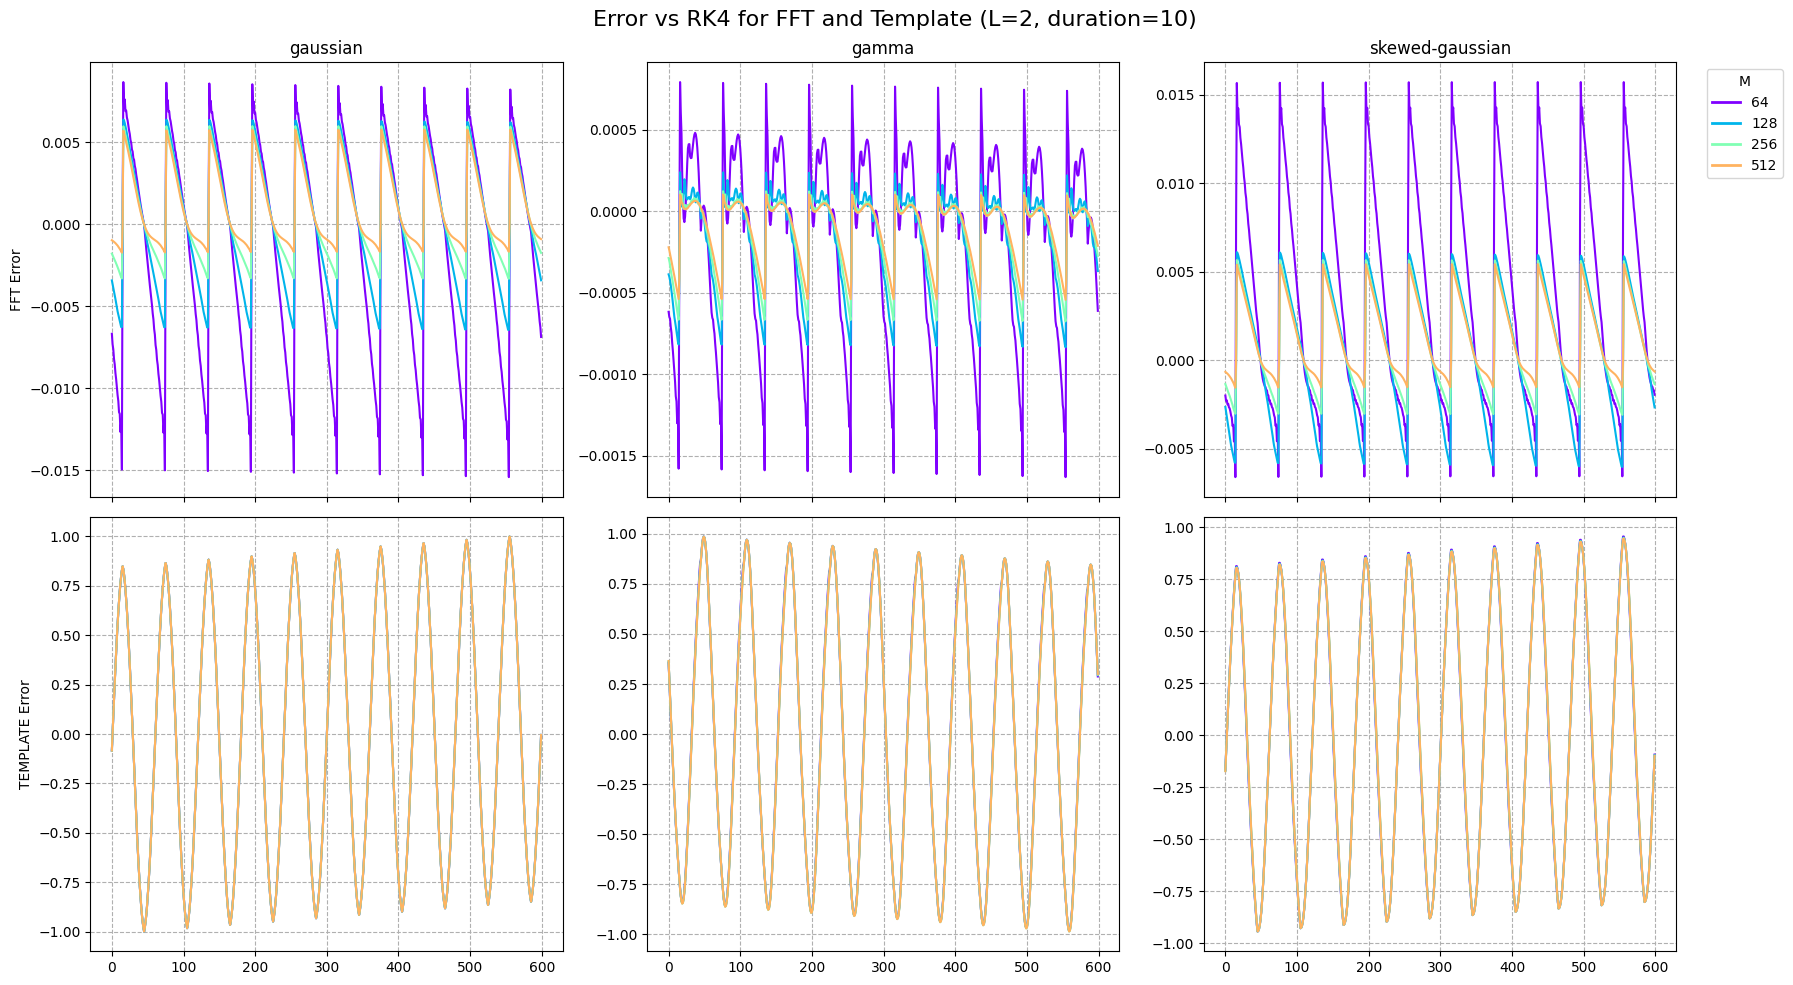

In [ ]:
def plot_gen_accuracy_vs_M(
    df: pd.DataFrame,
    duration: int,
    fixed_L: int,
    basis_types: list[str],
    Ms: list[int],
    output_path: str
) -> None:
    plot_methods = ["fft", "template"]

    fig, axes = plt.subplots(2, 3, figsize=(18,10), sharex=True)

    row_ymins = [float("inf")] * len(plot_methods)
    row_ymaxs = [float("-inf")] * len(plot_methods)

    for row_idx, method in enumerate(plot_methods):
        for col_idx, basis_type in enumerate(basis_types):
            ax = axes[row_idx][col_idx]

            subset = df[
                (df["basis_type"] == basis_type) &
                (df["duration"] == duration) &
                (df["L"] == fixed_L) &
                (df["method"] == method)
            ]

            for m_idx, M in enumerate(Ms):
                line_df = subset[subset["M"] == M].sort_values("sample_idx")
                y = line_df["error"]

                ax.plot(
                    line_df["sample_idx"],
                    y,
                    color=Ls_colors[m_idx]
                )

                if len(y) > 0:
                    row_ymins[row_idx] = min(row_ymins[row_idx], y.min())
                    row_ymaxs[row_idx] = max(row_ymaxs[row_idx], y.max())

            if row_idx == 0:
                ax.set_title(f"{basis_type}")

            if col_idx == 0:
                ax.set_ylabel(f"{method.upper()} Error")

            ax.grid(True, which="both", ls="--")

    for ax in axes[-1]:
        ax.set_xlabel("Sample")

    M_handles = [Line2D([0], [0], color=Ls_colors[i], lw=2) for i in range(len(Ms))]
    axes[0][2].legend(
        M_handles,
        Ms,
        title="M",
        loc="upper left",
        bbox_to_anchor=(1.05, 1)
    )

    fig.suptitle(
        f"Error vs RK4 for FFT and Template (L={fixed_L}, duration={duration})",
        fontsize=16
    )

    plt.tight_layout()
    plt.savefig(output_path, dpi=1400)
    plt.show()

gen_accuracy_df = pd.read_csv("./recover_test_csv/gen_accuracy_analysis.csv")

plot_gen_accuracy_vs_M(
    df=gen_accuracy_df,
    duration=10,
    fixed_L=2,
    basis_types=basis_types,
    Ms=Ms,
    output_path="./recover_test_images/error_vs_M_all_basis.svg"
)

# Extractor Analysis

In [ ]:
def ext_method_analysis(basis_type: str) -> pd.DataFrame:
    rows = []
    for L in Ls:
        for method in methods:
            rows.append({
                "basis_type": basis_type,
                "method": method,
                "L": L,
                "runtime": timeit.timeit(
                    lambda: ext_pipeline(L, basis_type, method),
                    number=num_times
                )
            })
    return pd.DataFrame(rows)

ext_df = pd.concat([
    ext_method_analysis("gaussian"),
    ext_method_analysis("gamma"),
    ext_method_analysis("skewed-gaussian")
], ignore_index=True)

ext_df.to_csv("./recover_test_csv/ext_method_analysis.csv", index=False)

## Extractor: Runtime Comparison between Methods

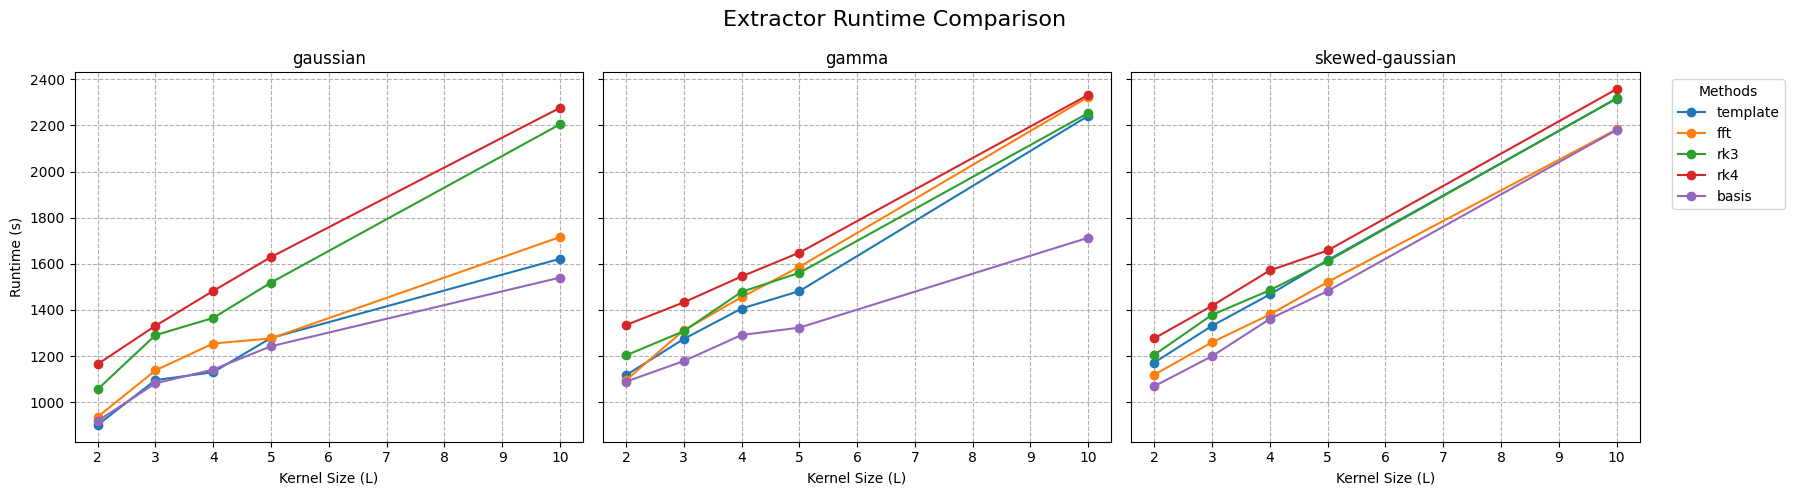

In [40]:
def plot_ext_all_methods(
    df: pd.DataFrame,
    basis_types: list[str],
    output_path: str
) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(18,5), sharey=True)
    for ax, basis_type in zip(axes, basis_types):
        subset = df[df["basis_type"] == basis_type]
        for method in methods:
            line_df = subset[subset["method"] == method].sort_values("L")
            ax.plot(
                line_df["L"],
                line_df["runtime"],
                marker="o",
                label = method
            )
        ax.set_title(basis_type)
        ax.set_xlabel("Kernel Size (L)")
        ax.grid(True, which="both", ls="--")

    axes[0].set_ylabel("Runtime (s)")

    handles, labels = axes[0].get_legend_handles_labels()
    axes[2].legend(
        handles,
        labels,
        title="Methods",
        loc="upper left",
        bbox_to_anchor=(1.05, 1)
    )

    fig.suptitle("Extractor Runtime Comparison", fontsize=16)
    plt.tight_layout()
    plt.savefig(output_path, dpi=1400)
    plt.show()

ext_df = pd.read_csv("./recover_test_csv/ext_method_analysis.csv")

plot_ext_all_methods(
    df=ext_df,
    basis_types=basis_types,
    output_path="./recover_test_images/ext_all_methods.svg"
)